# Communities and Crime - UCI Machine Learning Repository

Notebook inicial para importar el dataset publico **Communities and Crime** desde `ucimlrepo`.

Dataset usado: `fetch_ucirepo(id=183)`.

## 1. Instalar dependencias

Ejecuta esta celda si todavia no tienes instalado `ucimlrepo` en tu entorno.

In [1]:
%pip install ucimlrepo pandas certifi

/Users/vivimunoz/ProyectoII/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


## 2. Importar el dataset

In [2]:
import os
import certifi
from ucimlrepo import fetch_ucirepo

# Helps Python/macOS validate HTTPS certificates when pandas reads the UCI CSV.
os.environ["SSL_CERT_FILE"] = certifi.where()

# Fetch dataset
communities_and_crime = fetch_ucirepo(id=183)

# Data as pandas DataFrames
X = communities_and_crime.data.features
y = communities_and_crime.data.targets

print("Features shape:", X.shape)
print("Targets shape:", y.shape)

Features shape: (1994, 127)
Targets shape: (1994, 1)


## 3. Vista rapida de los datos

In [3]:
X.head()

,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,PolicAveOTWorked,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop
0,8,?,?,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.29,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14
1,53,?,?,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,?,0.02,0.12,0.45,?,?,?,?,0.00,?
2,24,?,?,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,?,0.01,0.21,0.02,?,?,?,?,0.00,?
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,?,0.02,0.39,0.28,?,?,?,?,0.00,?
4,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,?,0.04,0.09,0.02,?,?,?,?,0.00,?


In [4]:
y.head()

,ViolentCrimesPerPop
0,0.20
1,0.67
2,0.43
3,0.12
4,0.03


## 4. Metadata e informacion de variables

In [5]:
communities_and_crime.metadata

{'uci_id': 183,
 'name': 'Communities and Crime',
 'repository_url': 'https://archive.ics.uci.edu/dataset/183/communities+and+crime',
 'data_url': 'https://archive.ics.uci.edu/static/public/183/data.csv',
 'abstract': 'Communities within the United States. The data combines socio-economic data from the 1990 US Census, law enforcement data from the 1990 US LEMAS survey, and crime data from the 1995 FBI UCR.',
 'area': 'Social Science',
 'tasks': ['Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 1994,
 'num_features': 127,
 'feature_types': ['Real'],
 'demographics': ['Race', 'Age', 'Income', 'Occupation'],
 'target_col': ['ViolentCrimesPerPop'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 2002,
 'last_updated': 'Mon Mar 04 2024',
 'dataset_doi': '10.24432/C53W3X',
 'creators': ['Michael Redmond'],
 'intro_paper': {'ID': 405,
  'type': 'NATIVE',
  'title': 'A data-driven software tool for enabling c

In [6]:
communities_and_crime.variables

,name,role,type,demographic,description,units,missing_values
0,state,Feature,Integer,NaN,None,None,no
1,county,Feature,Integer,NaN,None,None,yes
2,community,Feature,Integer,NaN,None,None,yes
3,communityname,Feature,Categorical,NaN,None,None,no
4,fold,Feature,Integer,NaN,None,None,no
...,...,...,...,...,...,...,...
123,LemasPctPolicOnPatr,Feature,Continuous,NaN,None,None,yes
124,LemasGangUnitDeploy,Feature,Integer,NaN,None,None,yes
125,LemasPctOfficDrugUn,Feature,Integer,NaN,None,None,no
126,PolicBudgPerPop,Feature,Integer,NaN,None,None,yes


## 5. Dataset combinado

Opcionalmente, unimos `X` e `y` en un solo DataFrame para exploracion.

In [7]:
df = X.join(y)
df.head()

,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,8,?,?,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,?,?,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,?,?,?,?,0.00,?,0.67
2,24,?,?,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,?,?,?,?,0.00,?,0.43
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,?,?,?,?,0.00,?,0.12
4,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,?,?,?,?,0.00,?,0.03


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Columns: 128 entries, state to ViolentCrimesPerPop
dtypes: float64(100), int64(2), str(26)
memory usage: 1.9 MB


In [9]:
columnas_no_predictivas = [
    "county",
    "community",
    "fold",
]

df = df.drop(columns=columnas_no_predictivas)


In [10]:
import numpy as np

df = df.replace("?", np.nan)

In [11]:

import pandas as pd

missing = df.isnull().sum()

missing_pct = (missing / len(df) * 100).round(2)
 
resumen_missing = pd.DataFrame({

     'cantidad': missing,

     'porcentaje': missing_pct

 }).query('cantidad > 0').sort_values('porcentaje', ascending=False)
 
print(f"Columnas con missing: {len(resumen_missing)}")

print(f"Columnas sin missing: {(missing == 0).sum()}")

print()

resumen_missing

Columnas con missing: 23
Columnas sin missing: 102



,cantidad,porcentaje
LemasSwornFT,1675,84.00
LemasSwFTPerPop,1675,84.00
LemasSwFTFieldOps,1675,84.00
LemasTotalReq,1675,84.00
LemasSwFTFieldPerPop,1675,84.00
LemasTotReqPerPop,1675,84.00
PolicReqPerOffic,1675,84.00
OfficAssgnDrugUnits,1675,84.00
PolicPerPop,1675,84.00
RacialMatchCommPol,1675,84.00


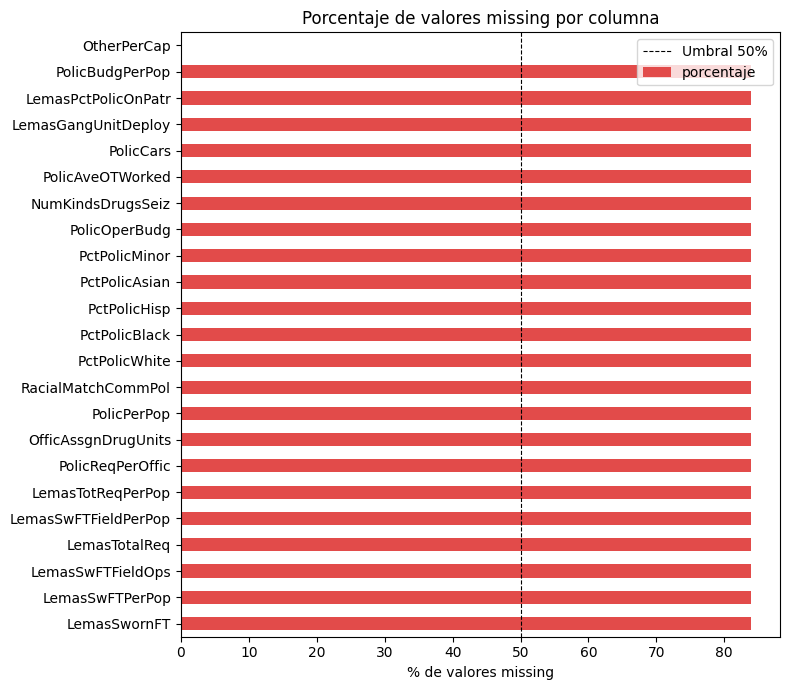

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 7))
 
colores = ['#E24B4A' if p >= 50 else '#F09595' for p in resumen_missing['porcentaje']]
 
resumen_missing['porcentaje'].plot(kind='barh', ax=ax, color=colores)
 
ax.axvline(x=50, color='black', linestyle='--', linewidth=0.8, label='Umbral 50%')

ax.set_xlabel('% de valores missing')

ax.set_title('Porcentaje de valores missing por columna')

ax.legend()
 
plt.tight_layout()

plt.show()

In [13]:
cols_lemas = [
    'LemasSwornFT', 'LemasSwFTPerPop', 'LemasSwFTFieldOps', 'LemasSwFTFieldPerPop',
    'LemasTotalReq', 'LemasTotReqPerPop', 'PolicReqPerOffic', 'PolicPerPop',
    'RacialMatchCommPol', 'PctPolicWhite', 'PctPolicBlack', 'PctPolicHisp',
    'PctPolicAsian', 'PctPolicMinor', 'OfficAssgnDrugUnits', 'NumKindsDrugsSeiz',
    'PolicAveOTWorked', 'PolicCars', 'PolicOperBudg', 'LemasPctPolicOnPatr',
    'LemasGangUnitDeploy', 'PolicBudgPerPop'
]

df = df.drop(columns=cols_lemas)

print(f"Columnas LEMAS eliminadas: {len(cols_lemas)}")
print(f"Dimensión resultante: {df.shape}")

Columnas LEMAS eliminadas: 22
Dimensión resultante: (1994, 103)


In [14]:
print(df['OtherPerCap'].dtype)
print(df['OtherPerCap'].unique()[:20])

str
<StringArray>
['0.36', '0.22', '0.28', '0.51', '0.48', '0.24', '0.18', '0.29', '0.17',
 '0.34', '0.35', '0.13', '0.33',  '0.2',    '1', '0.72',    '0', '0.19',
  '0.3', '0.38']
Length: 20, dtype: str


In [15]:
df['OtherPerCap'] = pd.to_numeric(df['OtherPerCap'], errors='coerce')

mediana_other = df['OtherPerCap'].median()
df['OtherPerCap'] = df['OtherPerCap'].fillna(mediana_other)

print(f"Tipo: {df['OtherPerCap'].dtype}")
print(f"Missing: {df['OtherPerCap'].isnull().sum()}")

Tipo: float64
Missing: 0


In [16]:
mediana_other = df['OtherPerCap'].median()

print(f"Media:   {df['OtherPerCap'].mean():.4f}")
print(f"Mediana: {mediana_other:.4f}")
print(f"Missing antes: {df['OtherPerCap'].isnull().sum()}")

df['OtherPerCap'] = df['OtherPerCap'].fillna(mediana_other)

print(f"Missing después: {df['OtherPerCap'].isnull().sum()}")

Media:   0.2847
Mediana: 0.2500
Missing antes: 0
Missing después: 0


In [17]:
print(f"Dimensión final: {df.shape}")
print(f"Missing totales: {df.isnull().sum().sum()}")
print(f"\n--- Tipos de datos ---")
print(df.dtypes.value_counts())
print(f"\n--- Primeras filas ---")
df.head()

Dimensión final: (1994, 103)
Missing totales: 0

--- Tipos de datos ---
float64    101
int64        1
str          1
Name: count, dtype: int64

--- Primeras filas ---


,state,communityname,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,...,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn,ViolentCrimesPerPop
0,8,Lakewoodcity,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,...,0.12,0.42,0.50,0.51,0.64,0.12,0.26,0.20,0.32,0.20
1,53,Tukwilacity,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,...,0.21,0.50,0.34,0.60,0.52,0.02,0.12,0.45,0.00,0.67
2,24,Aberdeentown,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,...,0.14,0.49,0.54,0.67,0.56,0.01,0.21,0.02,0.00,0.43
3,34,Willingborotownship,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,...,0.19,0.30,0.73,0.64,0.65,0.02,0.39,0.28,0.00,0.12
4,42,Bethlehemtownship,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,...,0.11,0.72,0.64,0.61,0.53,0.04,0.09,0.02,0.00,0.03


In [18]:
resumen = pd.DataFrame({
    'Paso': [
        'Dataset original',
        'Eliminar no predictivas (county, community, fold)',
        'Eliminar LEMAS (84% missing)',
        'Convertir OtherPerCap + imputar mediana'
    ],
    'Columnas': [128, 125, 103, 103],
    'Missing totales': [28910, 27733, 1, 0],
    'Decisión': [
        'Carga inicial',
        'No aportan al modelo según documentación',
        'Imputar >80% missing introduce sesgo masivo',
        'Solo 1 missing, mediana robusta ante outliers'
    ]
})

resumen

,Paso,Columnas,Missing totales,Decisión
0,Dataset original,128,28910,Carga inicial
1,"Eliminar no predictivas (county, community, fold)",125,27733,No aportan al modelo según documentación
2,Eliminar LEMAS (84% missing),103,1,Imputar >80% missing introduce sesgo masivo
3,Convertir OtherPerCap + imputar mediana,103,0,"Solo 1 missing, mediana robusta ante outliers"


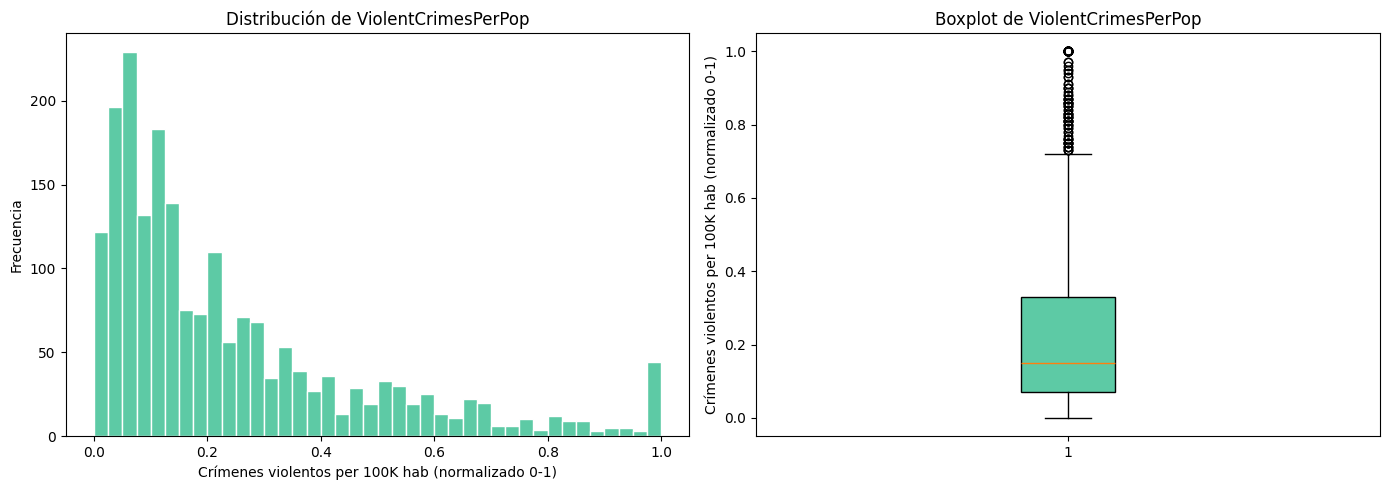

Media:    0.2380
Mediana:  0.1500
Skewness: 1.5226


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['ViolentCrimesPerPop'], bins=40, color='#5DCAA5', edgecolor='white')
axes[0].set_title('Distribución de ViolentCrimesPerPop')
axes[0].set_xlabel('Crímenes violentos per 100K hab (normalizado 0-1)')
axes[0].set_ylabel('Frecuencia')

# Boxplot
axes[1].boxplot(df['ViolentCrimesPerPop'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#5DCAA5'))
axes[1].set_title('Boxplot de ViolentCrimesPerPop')
axes[1].set_ylabel('Crímenes violentos per 100K hab (normalizado 0-1)')

plt.tight_layout()
plt.show()

print(f"Media:    {df['ViolentCrimesPerPop'].mean():.4f}")
print(f"Mediana:  {df['ViolentCrimesPerPop'].median():.4f}")
print(f"Skewness: {df['ViolentCrimesPerPop'].skew():.4f}")

la distribución está sesgada a la derecha — la mayoría de comunidades tienen criminalidad baja, pero hay algunas con valores muy altos.

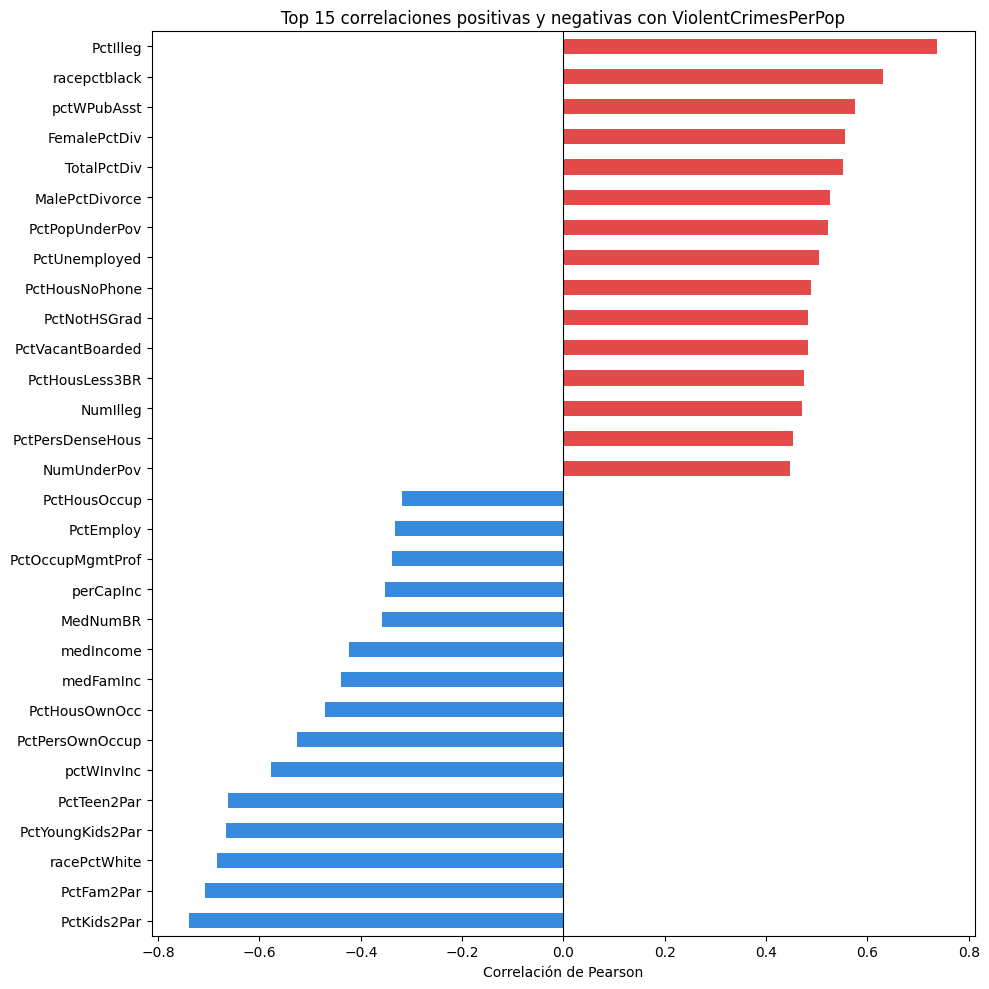

In [20]:
correlaciones = df.select_dtypes(include='number').corr()['ViolentCrimesPerPop'].drop('ViolentCrimesPerPop')
correlaciones = correlaciones.sort_values()

top15_pos = correlaciones.tail(15)
top15_neg = correlaciones.head(15)
top30 = pd.concat([top15_neg, top15_pos])

fig, ax = plt.subplots(figsize=(10, 10))

colores = ['#E24B4A' if c > 0 else '#378ADD' for c in top30]
top30.plot(kind='barh', ax=ax, color=colores)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Top 15 correlaciones positivas y negativas con ViolentCrimesPerPop')
ax.set_xlabel('Correlación de Pearson')

plt.tight_layout()
plt.show()

Correlación positiva (barras rojas) — cuando esa variable sube, el crimen también sube. Por ejemplo si PctIlleg (% de hijos de madres solteras) tiene correlación 0.74, significa que las comunidades con más hijos fuera del matrimonio tienden a tener más crimen. No significa que uno cause el otro, solo que van juntos.
Correlación negativa (barras azules) — cuando esa variable sube, el crimen baja. Por ejemplo PctKids2Par (% de niños con dos padres) tiene correlación -0.74, o sea las comunidades con más familias biparentales tienden a tener menos crimen.

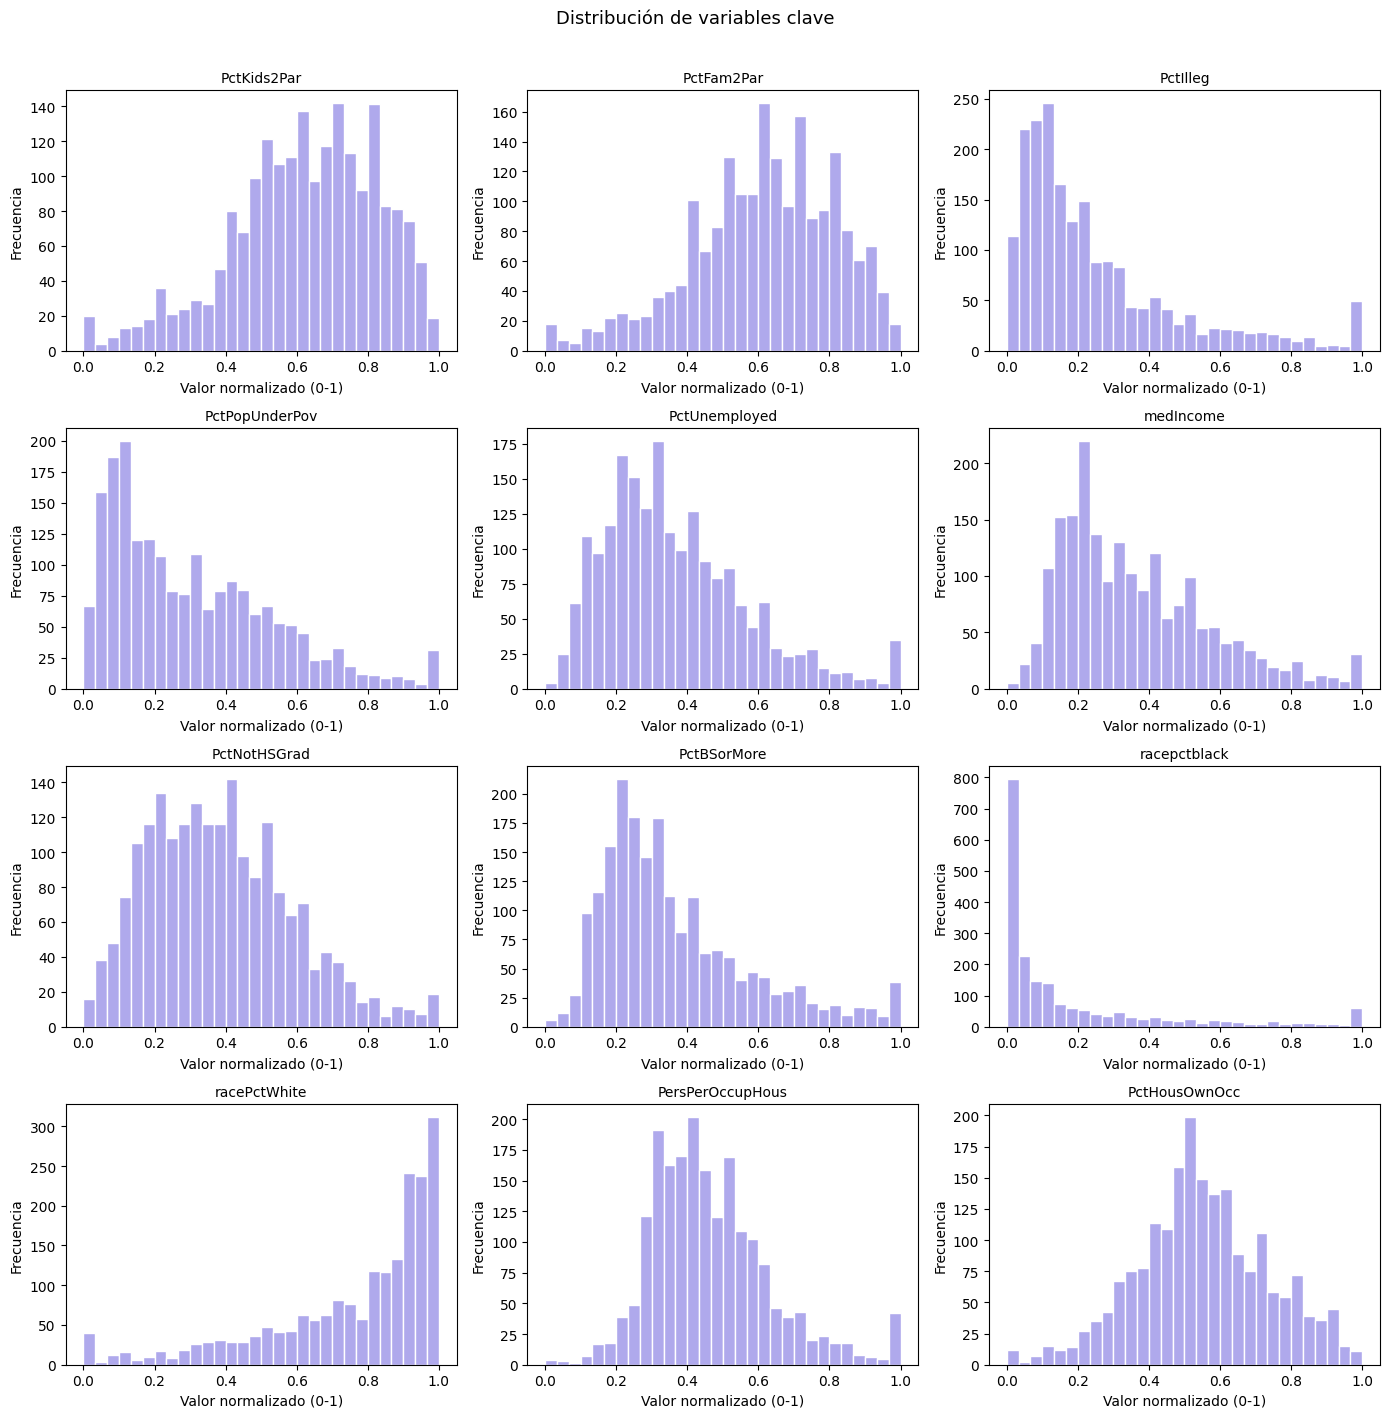

In [21]:
vars_interes = [
    'PctKids2Par', 'PctFam2Par', 'PctIlleg', 'PctPopUnderPov',
    'PctUnemployed', 'medIncome', 'PctNotHSGrad', 'PctBSorMore',
    'racepctblack', 'racePctWhite', 'PersPerOccupHous', 'PctHousOwnOcc'
]

fig, axes = plt.subplots(4, 3, figsize=(14, 14))
axes = axes.flatten()

for i, var in enumerate(vars_interes):
    axes[i].hist(df[var], bins=30, color='#AFA9EC', edgecolor='white')
    axes[i].set_title(var, fontsize=10)
    axes[i].set_xlabel('Valor normalizado (0-1)')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de variables clave', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

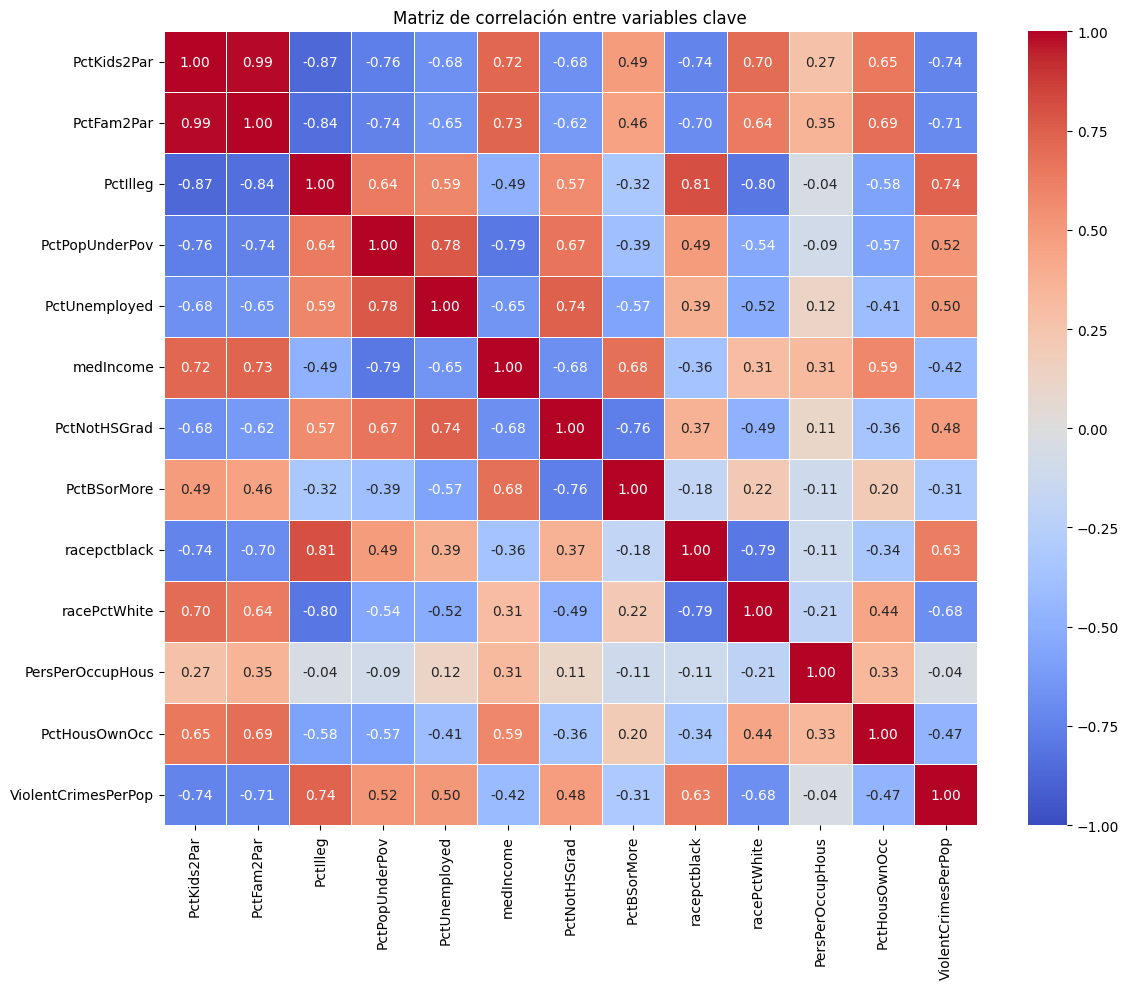

In [22]:
import seaborn as sns
vars_heatmap = [
    'PctKids2Par', 'PctFam2Par', 'PctIlleg', 'PctPopUnderPov',
    'PctUnemployed', 'medIncome', 'PctNotHSGrad', 'PctBSorMore',
    'racepctblack', 'racePctWhite', 'PersPerOccupHous', 'PctHousOwnOcc',
    'ViolentCrimesPerPop'
]

matriz_corr = df[vars_heatmap].corr()

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5
)

ax.set_title('Matriz de correlación entre variables clave')
plt.tight_layout()
plt.show()

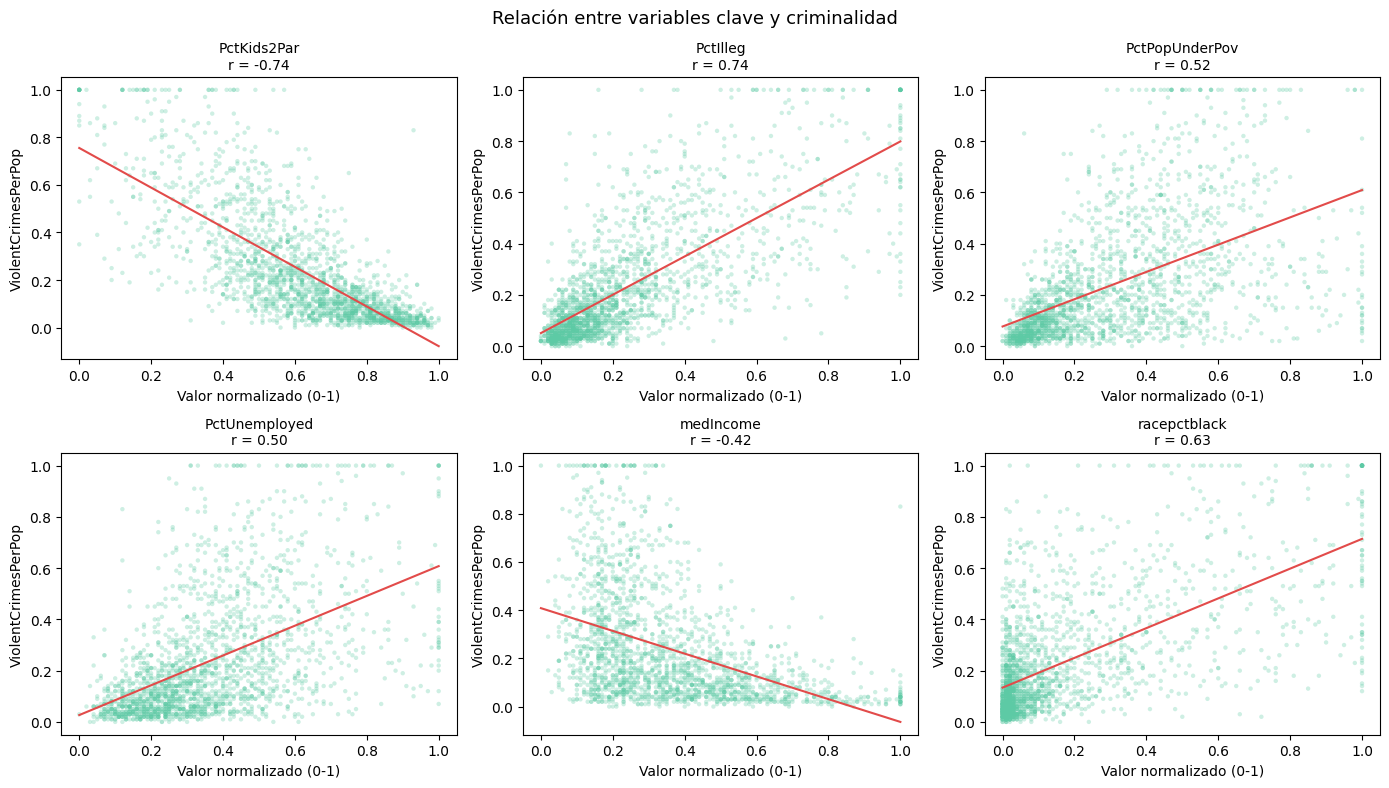

In [23]:
vars_scatter = [
    'PctKids2Par', 'PctIlleg', 'PctPopUnderPov',
    'PctUnemployed', 'medIncome', 'racepctblack'
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, var in enumerate(vars_scatter):
    axes[i].scatter(df[var], df['ViolentCrimesPerPop'],
                    alpha=0.3, color='#5DCAA5', edgecolors='none', s=10)
    
    # línea de tendencia
    z = np.polyfit(df[var], df['ViolentCrimesPerPop'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[var].min(), df[var].max(), 100)
    axes[i].plot(x_line, p(x_line), color='#E24B4A', linewidth=1.5)
    
    corr = df[var].corr(df['ViolentCrimesPerPop'])
    axes[i].set_title(f'{var}\nr = {corr:.2f}', fontsize=10)
    axes[i].set_xlabel('Valor normalizado (0-1)')
    axes[i].set_ylabel('ViolentCrimesPerPop')

plt.suptitle('Relación entre variables clave y criminalidad', fontsize=13)
plt.tight_layout()
plt.show()

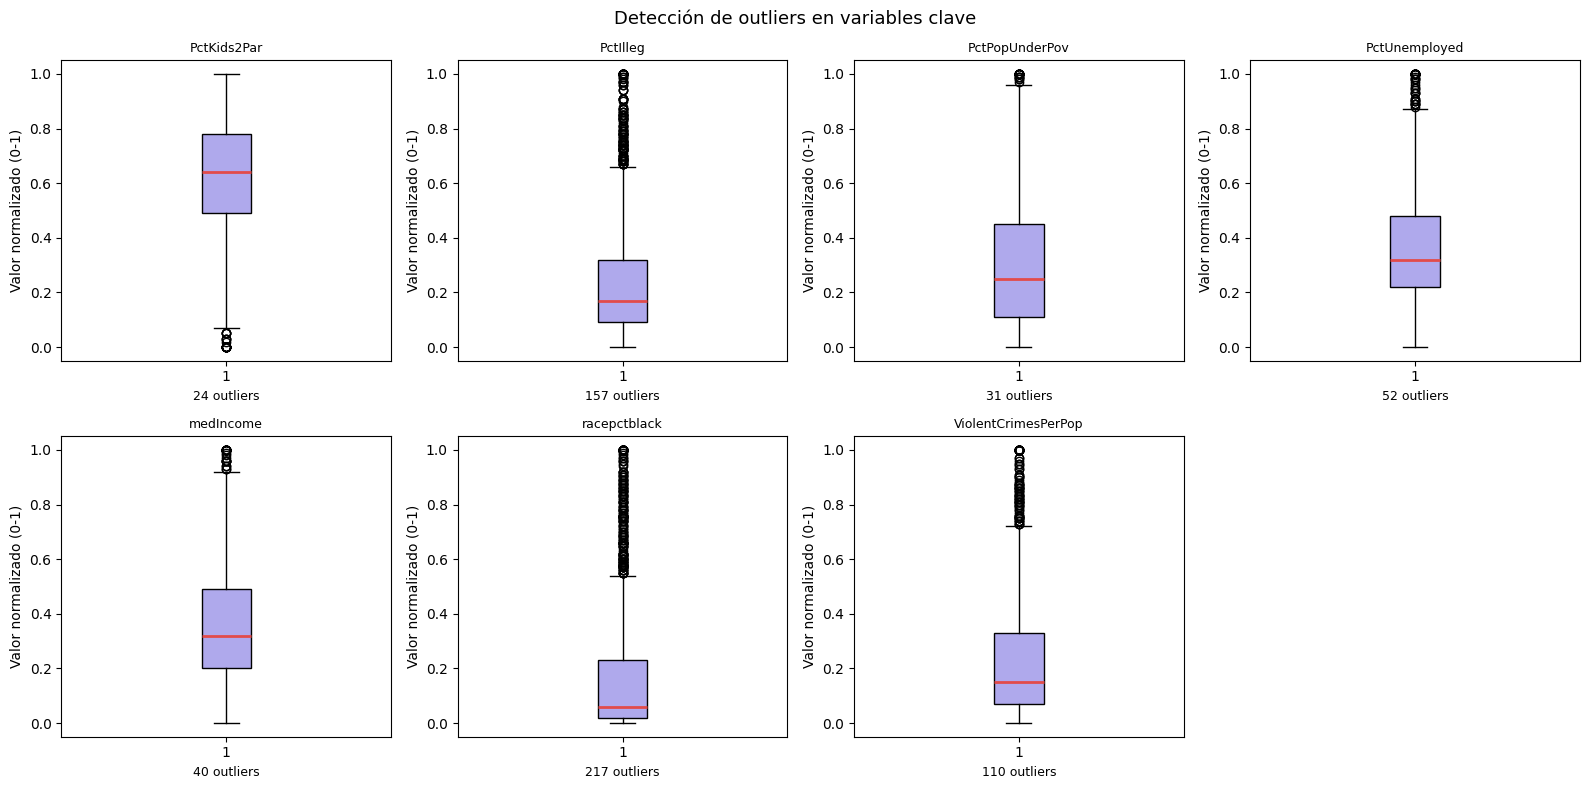

In [24]:
vars_outliers = [
    'PctKids2Par', 'PctIlleg', 'PctPopUnderPov',
    'PctUnemployed', 'medIncome', 'racepctblack',
    'ViolentCrimesPerPop'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, var in enumerate(vars_outliers):
    axes[i].boxplot(df[var], patch_artist=True,
                    boxprops=dict(facecolor='#AFA9EC'),
                    medianprops=dict(color='#E24B4A', linewidth=2))
    axes[i].set_title(var, fontsize=9)
    axes[i].set_ylabel('Valor normalizado (0-1)')
    
    # cuántos outliers hay
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df[var] < Q1 - 1.5*IQR) | (df[var] > Q3 + 1.5*IQR)).sum()
    axes[i].set_xlabel(f'{n_outliers} outliers', fontsize=9)

axes[-1].set_visible(False)

plt.suptitle('Detección de outliers en variables clave', fontsize=13)
plt.tight_layout()
plt.show()

/var/folders/jg/mz200w_s1bz5dgbcrxsprkpr0000gn/T/ipykernel_5401/1827161709.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['nivel_crimen'] = pd.cut(


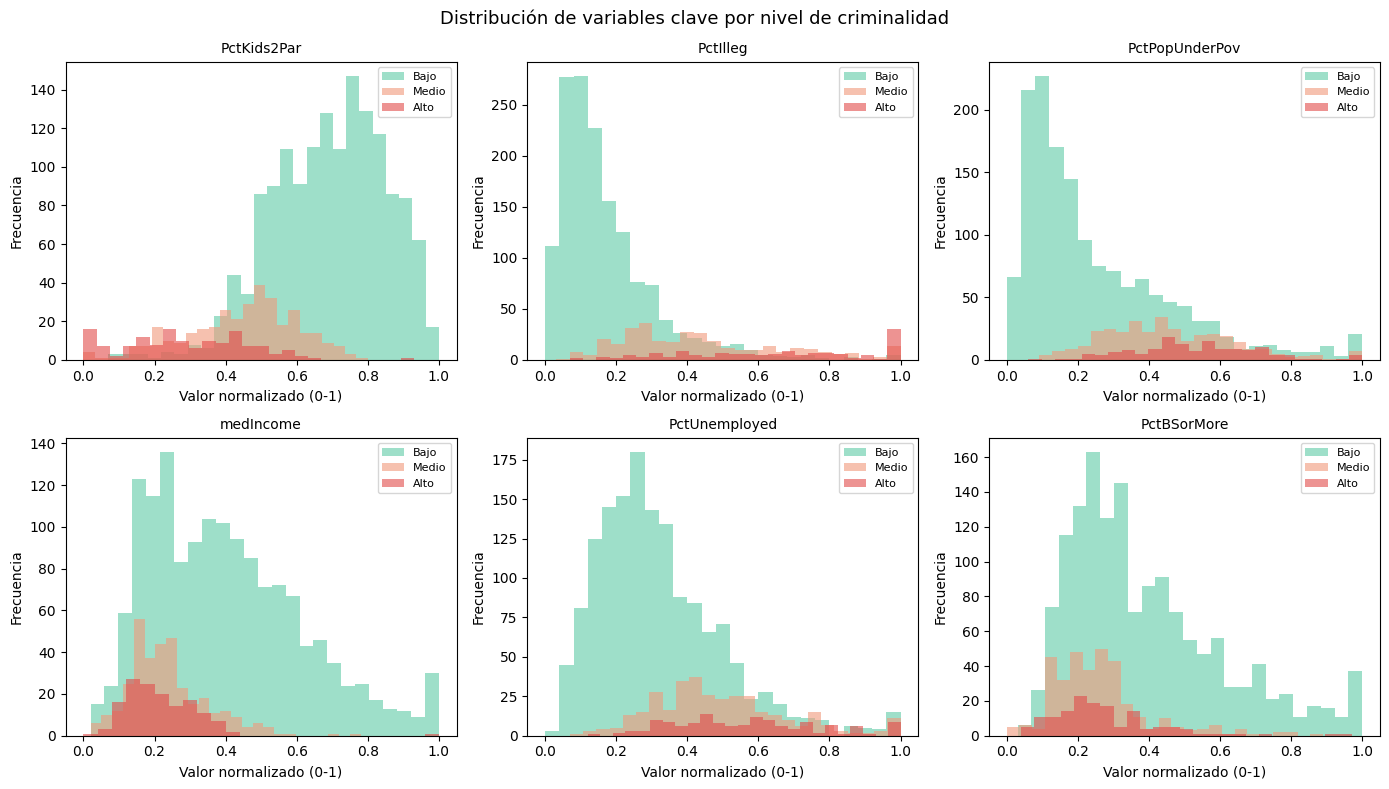

              PctKids2Par  PctIlleg  PctPopUnderPov  medIncome  PctUnemployed  \
nivel_crimen                                                                    
Bajo                0.691     0.168           0.246      0.402          0.315   
Medio               0.447     0.446           0.459      0.240          0.494   
Alto                0.287     0.649           0.532      0.213          0.565   

              PctBSorMore  
nivel_crimen               
Bajo                0.392  
Medio               0.262  
Alto                0.271  


In [25]:
df['nivel_crimen'] = pd.cut(
    df['ViolentCrimesPerPop'],
    bins=[0, 0.33, 0.66, 1],
    labels=['Bajo', 'Medio', 'Alto']
)

vars_comparar = [
    'PctKids2Par', 'PctIlleg', 'PctPopUnderPov',
    'medIncome', 'PctUnemployed', 'PctBSorMore'
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

colores = {'Bajo': '#5DCAA5', 'Medio': '#F0997B', 'Alto': '#E24B4A'}

for i, var in enumerate(vars_comparar):
    for nivel, grupo in df.groupby('nivel_crimen'):
        axes[i].hist(grupo[var], bins=25, alpha=0.6,
                     label=nivel, color=colores[nivel], edgecolor='none')
    axes[i].set_title(var, fontsize=10)
    axes[i].set_xlabel('Valor normalizado (0-1)')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de variables clave por nivel de criminalidad', fontsize=13)
plt.tight_layout()
plt.show()

print(df.groupby('nivel_crimen')[vars_comparar].mean().round(3))

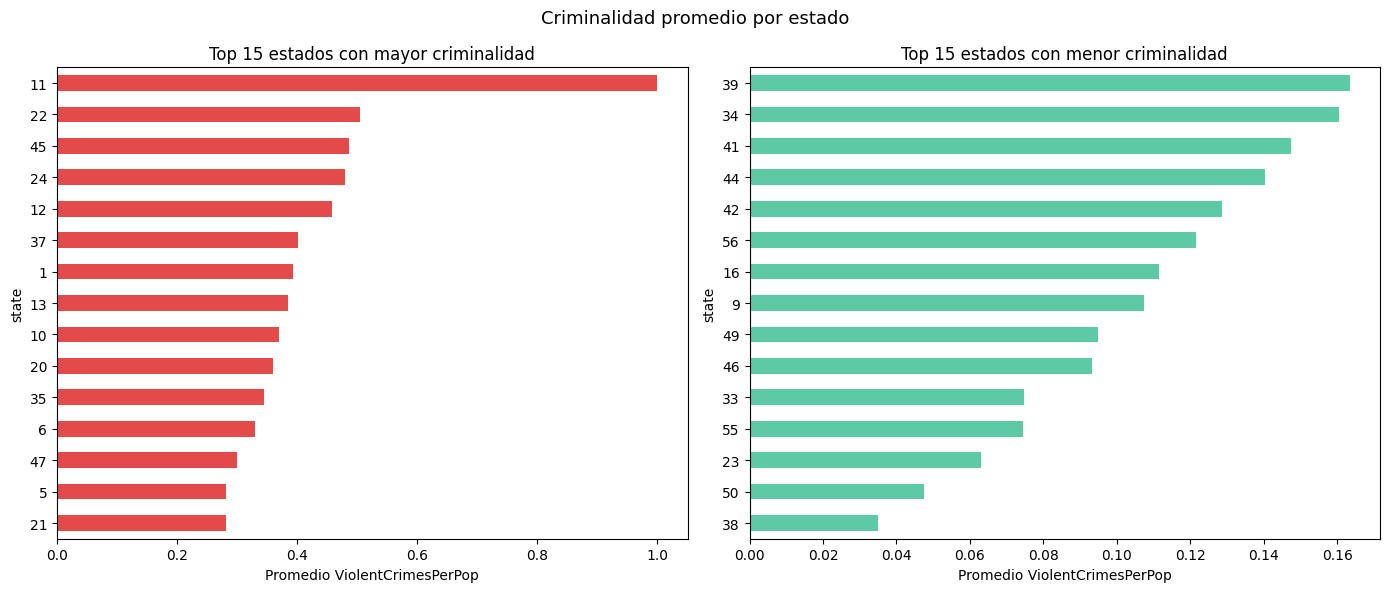

          media  mediana  n_comunidades
state                                  
11     1.000000    1.000              1
22     0.504545    0.470             22
45     0.486786    0.540             28
24     0.480000    0.445             12
12     0.458333    0.395             90
37     0.401957    0.380             46
1      0.393721    0.310             43
13     0.384054    0.350             37
10     0.370000    0.370              1
20     0.360000    0.360              1
35     0.345000    0.295             10
6      0.330468    0.265            278
47     0.299143    0.250             35
5      0.282000    0.210             25
21     0.281154    0.235             26
28     0.273158    0.230             19
48     0.255321    0.215            156
36     0.253696    0.170             46
2      0.240000    0.310              3
4      0.227000    0.190             20
53     0.226000    0.170             40
32     0.226000    0.200              5
8      0.217200    0.140             25


In [26]:
crimen_estado = df.groupby('state')['ViolentCrimesPerPop'].agg(['mean', 'median', 'count'])
crimen_estado.columns = ['media', 'mediana', 'n_comunidades']
crimen_estado = crimen_estado.sort_values('media', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 15 estados más peligrosos
crimen_estado.head(15)['media'].plot(
    kind='barh', ax=axes[0], color='#E24B4A'
)
axes[0].set_title('Top 15 estados con mayor criminalidad')
axes[0].set_xlabel('Promedio ViolentCrimesPerPop')
axes[0].invert_yaxis()

# Top 15 estados más seguros
crimen_estado.tail(15)['media'].plot(
    kind='barh', ax=axes[1], color='#5DCAA5'
)
axes[1].set_title('Top 15 estados con menor criminalidad')
axes[1].set_xlabel('Promedio ViolentCrimesPerPop')
axes[1].invert_yaxis()

plt.suptitle('Criminalidad promedio por estado', fontsize=13)
plt.tight_layout()
plt.show()

print(crimen_estado)

In [27]:
resumen_estadistico = df.select_dtypes(include='number').describe().T
resumen_estadistico['cv'] = (resumen_estadistico['std'] / resumen_estadistico['mean']).round(3)

resumen_estadistico = resumen_estadistico[['mean', 'std', 'cv', 'min', '25%', '50%', '75%', 'max']]
resumen_estadistico.columns = ['media', 'std', 'cv', 'min', 'p25', 'mediana', 'p75', 'max']
resumen_estadistico = resumen_estadistico.round(3)

resumen_estadistico

,media,std,cv,min,p25,mediana,p75,max
state,28.684,16.398,0.572,1.0,12.00,34.00,42.00,56.0
population,0.058,0.127,2.204,0.0,0.01,0.02,0.05,1.0
householdsize,0.463,0.164,0.353,0.0,0.35,0.44,0.54,1.0
racepctblack,0.180,0.253,1.411,0.0,0.02,0.06,0.23,1.0
racePctWhite,0.754,0.244,0.324,0.0,0.63,0.85,0.94,1.0
...,...,...,...,...,...,...,...,...
LandArea,0.065,0.109,1.678,0.0,0.02,0.04,0.07,1.0
PopDens,0.233,0.203,0.872,0.0,0.10,0.17,0.28,1.0
PctUsePubTrans,0.162,0.229,1.417,0.0,0.02,0.07,0.19,1.0
LemasPctOfficDrugUn,0.094,0.240,2.555,0.0,0.00,0.00,0.00,1.0


# Análisis Exploratorio de Datos — Communities and Crime

## Dataset
El dataset combina datos socioeconómicos del censo de 1990, datos de
aplicación de la ley (LEMAS) y datos de criminalidad del FBI de 1995
para comunidades de Estados Unidos. Tras la limpieza quedaron
*1,994 comunidades* y *103 variables*.

## Limpieza
Se eliminaron 25 columnas en total:
•⁠  ⁠*3 no predictivas* (county, community, fold) por definición del dataset
•⁠  ⁠*22 columnas LEMAS* con 84% de valores missing, provenientes de una
  encuesta policial con cobertura limitada. Imputar ese volumen de datos
  hubiera introducido un sesgo inaceptable.
•⁠  ⁠*OtherPerCap* tenía 1 solo missing, se imputó con la mediana.

## Hallazgos principales

### Variable objetivo
⁠ ViolentCrimesPerPop ⁠ tiene una distribución sesgada a la derecha —
la mayoría de comunidades presentan criminalidad baja, pero existe
una cola de comunidades con valores extremadamente altos. Esto sugiere
que un modelo de regresión deberá manejar esta asimetría.

### Factores más asociados al crimen
Las variables con mayor correlación positiva con la criminalidad son:
•⁠  ⁠⁠ PctIlleg ⁠ (r = 0.74) — % de hijos de madres solteras
•⁠  ⁠⁠ PctPopUnderPov ⁠ (r = 0.52) — % de población bajo la línea de pobreza
•⁠  ⁠⁠ PctUnemployed ⁠ (r = 0.50) — % de desempleo
•⁠  ⁠⁠ racepctblack ⁠ (r = 0.63) — % de población afroamericana

Las variables con mayor correlación negativa (protectoras):
•⁠  ⁠⁠ PctKids2Par ⁠ (r = -0.74) — % de niños con dos padres
•⁠  ⁠⁠ PctFam2Par ⁠ (r = -0.71) — % de familias biparentales
•⁠  ⁠⁠ medIncome ⁠ (r = -0.42) — ingreso mediano del hogar
•⁠  ⁠⁠ PctBSorMore ⁠ (r = -0.31) — % de población con educación universitaria

### Multicolinealidad
La matriz de correlación revela alta correlación entre variables del
mismo grupo temático — por ejemplo ⁠ PctKids2Par ⁠ y ⁠ PctFam2Par ⁠
tienen r > 0.95. Esto deberá tenerse en cuenta en el modelado,
especialmente si se usa regresión lineal.

### Outliers
Se detectaron outliers en la mayoría de variables, especialmente en
⁠ ViolentCrimesPerPop ⁠, ⁠ PctIlleg ⁠ y ⁠ racepctblack ⁠. Estas comunidades
atípicas pueden influir desproporcionadamente en los modelos.

### Patrones geográficos
Existe variabilidad significativa en la criminalidad entre estados,
lo que sugiere que la ubicación geográfica podría ser un factor
relevante para el modelo.

## Conclusión
Los factores más asociados a la criminalidad son de naturaleza
socioeconómica y familiar, no policial. La estructura familiar
(familias biparentales) y el nivel de pobreza aparecen como los
predictores más fuertes, lo cual es consistente con la literatura
criminológica.